# 03 · Gols por minuto

Aqui uso a base de gols, que traz o minuto de cada um dos 9.861 gols da Série A de 2014 a 2024. As perguntas:

1. Em que momento do jogo saem mais gols?
2. O fim do jogo é mesmo decisivo?
3. Alguma coisa mudou nos acréscimos nos últimos anos?

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

from src.dados import carregar_gols, carregar_partidas
from src.graficos import (
    AZUL, EIXO, LARANJA, SUPERFICIE, TINTA, TINTA_SECUNDARIA,
    aplicar_estilo, eixo_percentual, fonte, salvar, titulo,
)

aplicar_estilo()
gols = carregar_gols()
partidas = carregar_partidas()

## Quando saem os gols

In [2]:
por_faixa = gols["faixa"].value_counts(normalize=True, sort=False)
por_faixa.round(3)

faixa
0-15     0.122
16-30    0.135
31-45    0.152
45+      0.035
46-60    0.157
61-75    0.165
76-90    0.166
90+      0.069
Name: proportion, dtype: float64

In [3]:
gols["tempo"].value_counts(normalize=True).sort_index().round(3)

tempo
1    0.443
2    0.557
Name: proportion, dtype: float64

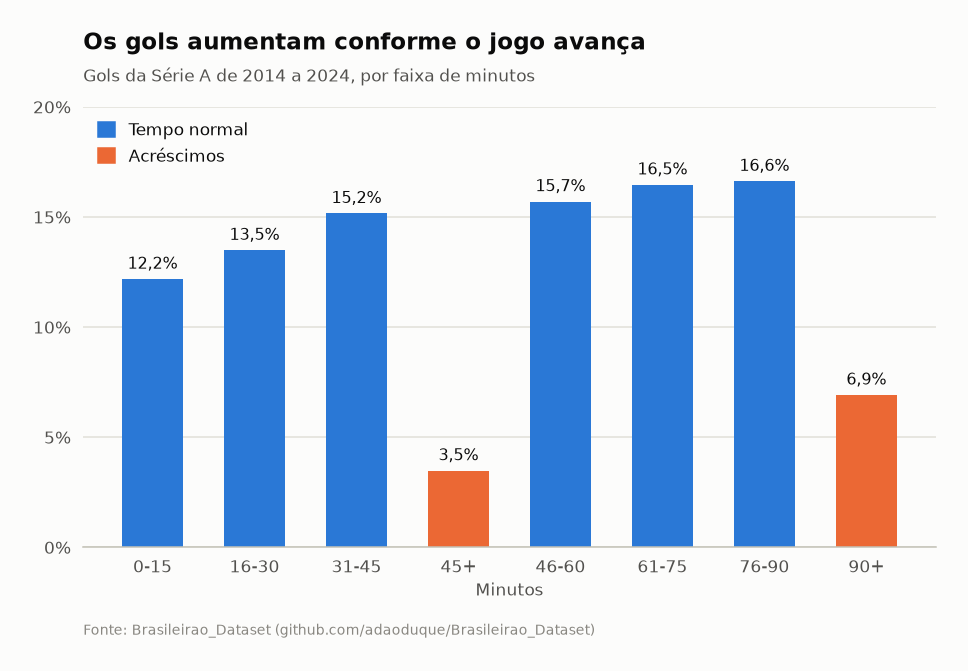

In [4]:
cores = [LARANJA if faixa.endswith("+") else AZUL for faixa in por_faixa.index]

fig, ax = plt.subplots(figsize=(10, 5.2))
barras = ax.bar(por_faixa.index.astype(str), por_faixa.values, width=0.6, color=cores)

for barra, valor in zip(barras, por_faixa.values):
    ax.text(
        barra.get_x() + barra.get_width() / 2, valor + 0.003,
        f"{valor:.1%}".replace(".", ","),
        ha="center", va="bottom", fontsize=10.5, color=TINTA,
    )

ax.set_ylim(0, 0.20)
ax.set_yticks(np.arange(0, 0.21, 0.05))
eixo_percentual(ax.yaxis)
ax.set_xlabel("Minutos")
ax.legend(
    handles=[Patch(color=AZUL, label="Tempo normal"), Patch(color=LARANJA, label="Acréscimos")],
    loc="upper left", handlelength=1, handleheight=1,
)

titulo(ax, "Os gols aumentam conforme o jogo avança", "Gols da Série A de 2014 a 2024, por faixa de minutos")
fonte(ax, deslocamento=-50)
salvar(fig, "gols_por_faixa.png")
plt.show()

O 2º tempo concentra 55,7% dos gols, contra 44,3% do 1º. E dentro de cada tempo a frequência sobe faixa a faixa: os primeiros 15 minutos têm 12,2% dos gols, e a faixa dos 76 aos 90, 16,6%. Faz sentido com o que se vê em campo: cansaço, substituições e o time que está perdendo se arriscando mais.

Os acréscimos chamam atenção. Duram poucos minutos e mesmo assim somam 10,4% de todos os gols (3,5% no fim do 1º tempo e 6,9% no fim do 2º).

## O fim do jogo é decisivo

Para medir isso, reconstruí o placar de cada partida em um minuto de corte e comparei com o resultado final. Se o resultado no corte é diferente do final, o jogo foi decidido depois dele.

In [5]:
def calcular_resultado(gols_mandante, gols_visitante):
    return np.select(
        [gols_mandante > gols_visitante, gols_mandante < gols_visitante],
        ["mandante", "visitante"],
        default="empate",
    )


def resultado_no_minuto(minuto):
    ate_o_corte = gols[gols["minuto_ordem"] <= minuto]
    placar = ate_o_corte.groupby("partida_id")["gol_mandante"].agg(mandante="sum", total="size")
    placar["visitante"] = placar["total"] - placar["mandante"]

    jogos = partidas.loc[partidas["temporada"] >= 2014, ["id", "temporada", "resultado"]].set_index("id")
    jogos = jogos.join(placar[["mandante", "visitante"]]).fillna({"mandante": 0, "visitante": 0})
    jogos["resultado_no_corte"] = calcular_resultado(jogos["mandante"], jogos["visitante"])
    jogos["mudou"] = jogos["resultado_no_corte"] != jogos["resultado"]
    return jogos


for minuto in [75, 80, 90]:
    jogos = resultado_no_minuto(minuto)
    print(f"Resultado mudou depois dos {minuto} minutos: {jogos['mudou'].sum()} jogos ({jogos['mudou'].mean():.1%})")

Resultado mudou depois dos 75 minutos: 927 jogos (22.2%)
Resultado mudou depois dos 80 minutos: 747 jogos (17.9%)
Resultado mudou depois dos 90 minutos: 327 jogos (7.8%)


Quase 1 em cada 5 jogos (17,9%) muda de resultado depois dos 80 minutos, e 7,8% mudam só nos acréscimos do 2º tempo. São 327 partidas em 11 temporadas em que o placar que valia aos 90 minutos não foi o placar final.

## Os acréscimos ficaram mais decisivos

Olhando temporada por temporada, em SQL:

In [6]:
por_temporada = duckdb.sql("""
    SELECT
        temporada,
        COUNT(*) AS gols,
        COUNT(*) FILTER (WHERE acrescimo > 0) AS gols_acrescimo,
        AVG(CASE WHEN acrescimo > 0 THEN 1 ELSE 0 END) AS pct_acrescimo,
        COUNT(*) FILTER (WHERE tipo_de_gol = 'Penalty') AS gols_penalti,
        AVG(CASE WHEN tipo_de_gol = 'Penalty' THEN 1 ELSE 0 END) AS pct_penalti
    FROM gols
    GROUP BY temporada
    ORDER BY temporada
""").df().set_index("temporada")

decididos_no_acrescimo = resultado_no_minuto(90).groupby("temporada")["mudou"].mean()
por_temporada["pct_jogos_decididos_acrescimo"] = decididos_no_acrescimo

por_temporada.round(3)

,gols,gols_acrescimo,pct_acrescimo,gols_penalti,pct_penalti,pct_jogos_decididos_acrescimo
temporada,,,,,,
2014,860,61,0.071,62,0.072,0.061
2015,897,71,0.079,73,0.081,0.058
2016,912,62,0.068,79,0.087,0.047
2017,923,85,0.092,89,0.096,0.063
2018,827,77,0.093,72,0.087,0.076
2019,876,101,0.115,94,0.107,0.087
2020,944,108,0.114,111,0.118,0.097
2021,842,107,0.127,86,0.102,0.103
2022,905,107,0.118,98,0.108,0.089


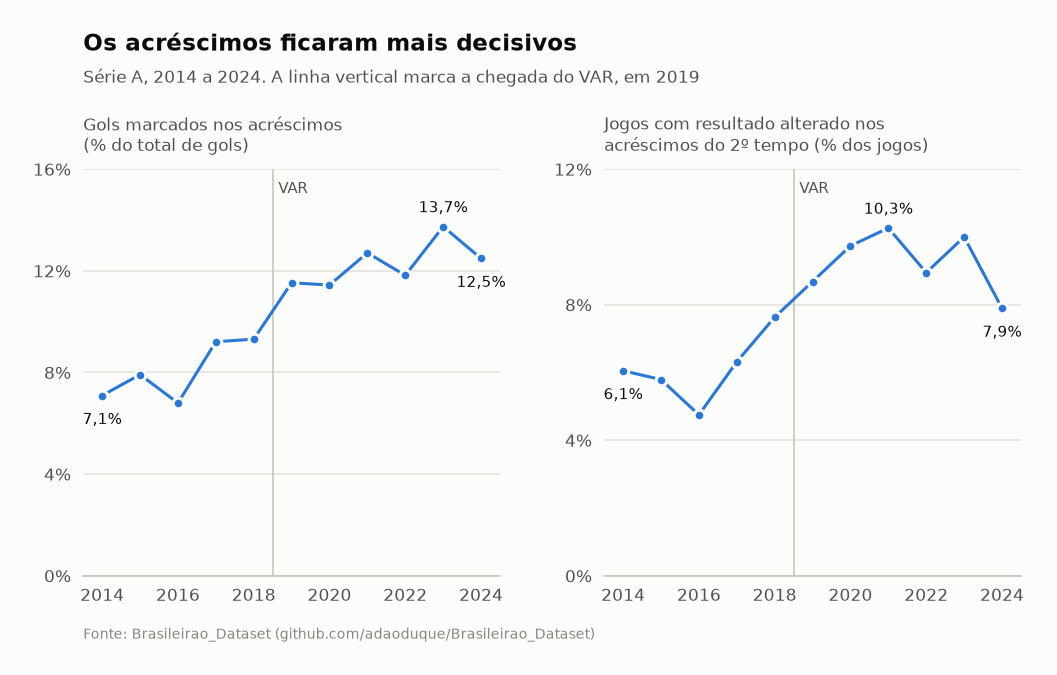

In [7]:
paineis = [
    ("pct_acrescimo", "Gols marcados nos acréscimos\n(% do total de gols)", 0.16),
    ("pct_jogos_decididos_acrescimo", "Jogos com resultado alterado nos\nacréscimos do 2º tempo (% dos jogos)", 0.12),
]

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True)

for ax, (coluna, nome, limite) in zip(eixos, paineis):
    serie = por_temporada[coluna]
    ax.axvline(2018.5, color=EIXO, linewidth=1, zorder=1)
    ax.text(2018.65, limite * 0.97, "VAR", va="top", fontsize=10, color=TINTA_SECUNDARIA)
    ax.plot(
        serie.index, serie.values, color=AZUL, marker="o", markersize=7,
        markeredgecolor=SUPERFICIE, markeredgewidth=2, zorder=3,
    )
    for ano in [2014, 2024]:
        ax.annotate(
            f"{serie[ano]:.1%}".replace(".", ","), xy=(ano, serie[ano]),
            xytext=(0, -16), textcoords="offset points",
            ha="center", va="center", fontsize=10, color=TINTA,
        )
    ano_max = serie.idxmax()
    ax.annotate(
        f"{serie[ano_max]:.1%}".replace(".", ","), xy=(ano_max, serie[ano_max]),
        xytext=(0, 12), textcoords="offset points",
        ha="center", va="center", fontsize=10, color=TINTA,
    )
    ax.set_title(nome, loc="left", fontsize=11, color=TINTA_SECUNDARIA, pad=12)
    ax.set_ylim(0, limite)
    ax.set_yticks(np.arange(0, limite + 0.001, 0.04))
    ax.set_xticks(range(2014, 2025, 2))
    eixo_percentual(ax.yaxis)

titulo(eixos[0], "Os acréscimos ficaram mais decisivos", "Série A, 2014 a 2024. A linha vertical marca a chegada do VAR, em 2019", espaco=40)
fonte(eixos[0], deslocamento=-34)
fig.subplots_adjust(wspace=0.25)
salvar(fig, "acrescimos_por_temporada.png")
plt.show()

A fatia de gols nos acréscimos quase dobrou: era 7,1% em 2014 e chegou a 13,7% em 2023. E não são gols irrelevantes. De 2014 a 2017, entre 4,7% e 6,3% dos jogos tinham o resultado alterado nos acréscimos do 2º tempo; de 2019 a 2023, essa taxa ficou entre 8,7% e 10,3%. Em 2024 ela caiu para 7,9%, mas os gols nos acréscimos continuaram altos (12,5%).

A virada coincide com 2019, ano em que o VAR passou a ser usado em todos os jogos da Série A ([Folha Vitória](https://www.folhavitoria.com.br/esportes/cbf-implementa-o-uso-do-var-no-brasileirao-mas-preve-fase-de-adaptacao/)). As revisões de lance aumentam o tempo de bola parada, e o árbitro compensa nos acréscimos. A base não traz quantos minutos de acréscimo cada jogo teve, então isso fica como hipótese, mas a coincidência de datas é forte.

## E os pênaltis?

In [8]:
por_temporada[["gols_penalti", "pct_penalti"]].round(3)

,gols_penalti,pct_penalti
temporada,,
2014,62,0.072
2015,73,0.081
2016,79,0.087
2017,89,0.096
2018,72,0.087
2019,94,0.107
2020,111,0.118
2021,86,0.102
2022,98,0.108


In [9]:
antes_do_var = por_temporada.loc[2014:2018, "gols_penalti"].mean()
com_var = por_temporada.loc[2019:2023, "gols_penalti"].mean()

print(f"Média de gols de pênalti por temporada, 2014 a 2018: {antes_do_var:.0f}")
print(f"Média de gols de pênalti por temporada, 2019 a 2023: {com_var:.0f}")

Média de gols de pênalti por temporada, 2014 a 2018: 75
Média de gols de pênalti por temporada, 2019 a 2023: 97


Os gols de pênalti também subiram a partir de 2019: a média passou de 75 por temporada (2014 a 2018) para 97 (2019 a 2023), com pico de 111 em 2020. Em 2024 o número voltou ao patamar de antes (76), o que vale investigar em outra análise.

Um cuidado aqui: a base registra só pênaltis convertidos em gol. Pênalti perdido não aparece, então não dá pra saber se foram marcados mais pênaltis ou se a conversão melhorou.

## Conclusões

- **O 2º tempo tem mais gols que o 1º** (55,7% contra 44,3%), e a frequência de gols sobe conforme o jogo avança.
- **Os acréscimos valem ouro.** Concentram 10,4% dos gols mesmo durando poucos minutos.
- **O fim do jogo decide muito.** Quase 1 em cada 5 partidas muda de resultado depois dos 80 minutos.
- **Depois do VAR, os acréscimos ganharam peso**, com mais gols e mais jogos decididos nesse período. Os gols de pênalti também aumentaram entre 2019 e 2023.